The Normal Equation

In [2]:
#Test the Normal Equation
import numpy as np

In [3]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [4]:
import matplotlib.pyplot as plt

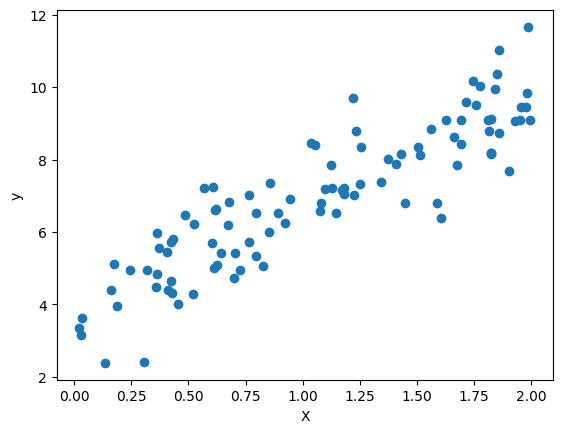

In [5]:
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [6]:
X_b = np.c_[np.ones((100, 1)), X]
X_b

array([[1.        , 1.58943447],
       [1.        , 0.4069281 ],
       [1.        , 0.82629574],
       [1.        , 1.03547201],
       [1.        , 0.61174697],
       [1.        , 0.45486351],
       [1.        , 0.42799217],
       [1.        , 1.75937984],
       [1.        , 0.61635032],
       [1.        , 0.60378238],
       [1.        , 0.62576496],
       [1.        , 0.31655396],
       [1.        , 0.30376098],
       [1.        , 0.36434506],
       [1.        , 1.82325518],
       [1.        , 1.18122753],
       [1.        , 1.42882322],
       [1.        , 0.17197085],
       [1.        , 1.85858442],
       [1.        , 0.6979412 ],
       [1.        , 1.56206276],
       [1.        , 0.42303201],
       [1.        , 1.97912001],
       [1.        , 1.1734831 ],
       [1.        , 0.56690012],
       [1.        , 0.35868913],
       [1.        , 0.67928382],
       [1.        , 0.61933765],
       [1.        , 1.67410869],
       [1.        , 1.9854239 ],
       [1.

In [7]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[3.81582869],
       [2.95974717]])

In [8]:
X_new = np.array([[0], [2]])
X_new

array([[0],
       [2]])

In [9]:
X_new_b = np.c_[np.ones((2, 1)), X_new]
X_new_b

array([[1., 0.],
       [1., 2.]])

In [10]:
y_predict = X_new_b.dot(theta_best)
y_predict

array([[3.81582869],
       [9.73532304]])

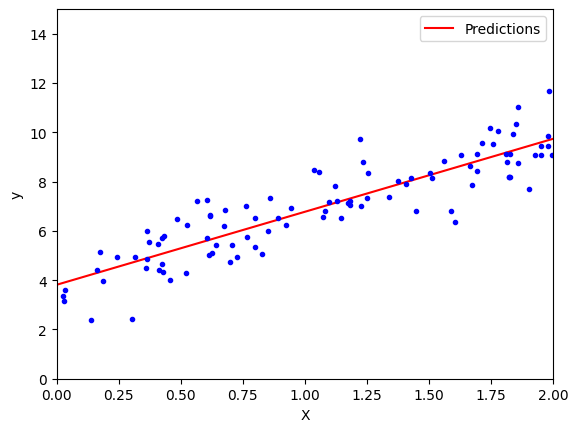

In [11]:
plt.plot(X_new, y_predict, 'r-', label='Predictions')
plt.plot(X, y, 'b.')
plt.axis([0, 2, 0, 15])
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [12]:
# Perform Linear Regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [13]:
lin_reg.fit(X,y)

LinearRegression()

In [14]:
lin_reg.intercept_, lin_reg.coef_

(array([3.81582869]), array([[2.95974717]]))

In [15]:
lin_reg.predict(X_new)

array([[3.81582869],
       [9.73532304]])

In [16]:
# Compare with the function Linear Regression is based on
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond = 1e-6)
theta_best_svd

array([[3.81582869],
       [2.95974717]])

In [17]:
# Compute the pseudoinverse directly
np.linalg.pinv(X_b).dot(y)

array([[3.81582869],
       [2.95974717]])

In [18]:
# Compute the Batch Gradient Descent
eta = 0.1 #learning rate
n_iterations = 1000
m = 100

In [19]:
theta = np.random.randn(2,1) #random initialization

In [20]:
for iteration in range (n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [21]:
theta

array([[3.81582869],
       [2.95974717]])

In [22]:
#Compute Stochastic Gradient Descent

n_epochs = 50 #rounds of iteration
t0, t1 = 5, 50 # learning schedule hyperparameters

In [23]:
def learning_schedule (t):
    return t0/(t + t1)

In [24]:
import numpy as np
theta = np.random.randn(2,1) #random initialization

In [25]:
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + 1)
        theta = theta - eta * gradients

In [26]:
theta

array([[3.82905215],
       [2.98494997]])

In [27]:
#Linear Regression using Stochastic GD
from sklearn.linear_model import SGDRegressor

In [28]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [29]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.79430649]), array([2.91540052]))

Polynomial Regression

In [30]:
#Generate nonlinear data
import numpy as np

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

Text(0, 0.5, 'y')

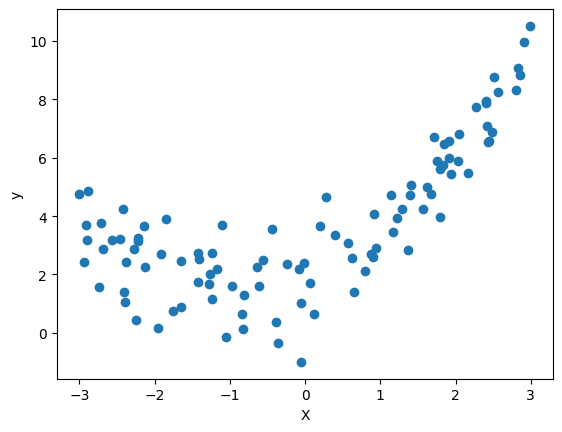

In [31]:
import matplotlib.pyplot as plt

plt.scatter (X, y)
plt.xlabel('X')
plt.ylabel('y')

In [32]:
#Transfor training data by adding the square of each feature (second-degree)
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [33]:
X[0]

array([1.38933479])

In [34]:
X_poly[0]

array([1.38933479, 1.93025117])

In [35]:
# Fit LinearRegression model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [36]:
lin_reg.fit(X_poly, y)

LinearRegression()

In [37]:
lin_reg.intercept_, lin_reg.coef_

(array([1.94241687]), array([[0.98346976, 0.54059403]]))

That means the model is y = 0.44x^2 + 0.90x + 2.25

The original function was y = 0.5x^2 + x + 2 + gaussian noise

In [38]:
new_X = np.linspace(-3, 3, 100).reshape(100, 1)
new_X_poly = poly_features.fit_transform(new_X)

In [39]:
y_predict = lin_reg.predict(new_X_poly)

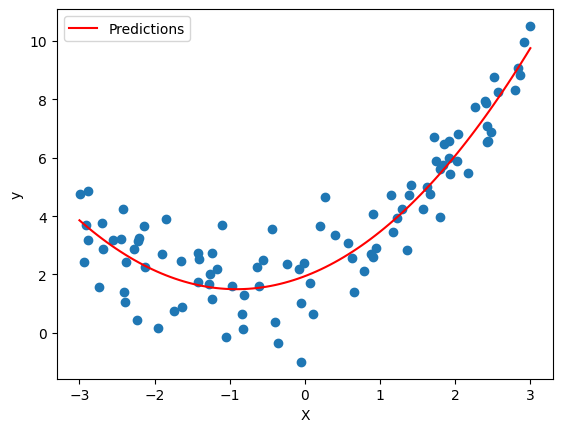

In [40]:
plt.scatter (X, y)
plt.plot(new_X, y_predict, '-', color='red', label='Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

Learning Curves

In [41]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [42]:
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errrors, val_errors = [], []

    for m in range (1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errrors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    
    plt.plot(np.sqrt(train_errrors), 'r-+', linewidth=2, label='train')
    plt.plot(np.sqrt(val_errors), 'b-', linewidth=3, label='val')
    plt.xlabel('Training set size')
    plt.ylabel('RMSE')
    plt.legend()

In [43]:
# Fit LinearRegression model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [44]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

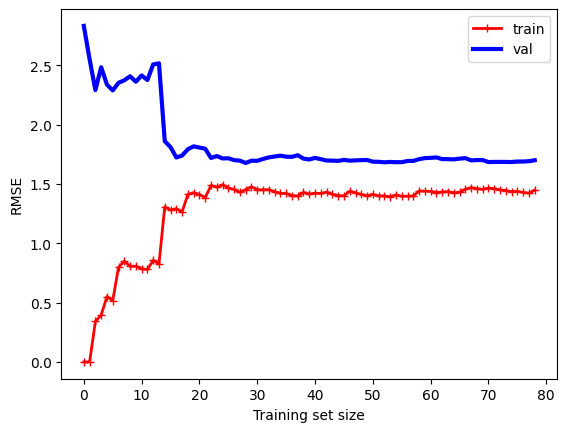

In [45]:
plot_learning_curves(lin_reg, X, y)

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [47]:
polynomial_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree=10, include_bias=False)),
    ('lin_reg', LinearRegression())
])

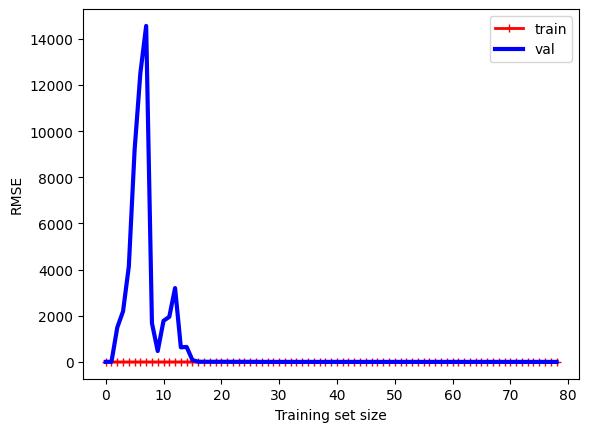

In [48]:
plot_learning_curves(polynomial_regression, X, y)

Regularized Linear Models

Ridge Regression

In [54]:
#Generate nonlinear data
import numpy as np

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

In [55]:
from sklearn.linear_model import Ridge

In [56]:
ridge_reg = Ridge(alpha=1, solver='cholesky')

In [57]:
ridge_reg.fit(X, y)

Ridge(alpha=1, solver='cholesky')

In [58]:
ridge_reg.predict([[1.5]])

array([4.84444654])

In [59]:
from sklearn.linear_model import SGDRegressor

In [60]:
sgd_reg = SGDRegressor(penalty='l2')

In [61]:
sgd_reg.fit(X, y.ravel())

SGDRegressor()

In [62]:
sgd_reg.predict([[1.5]])

array([4.82141675])

Lasso Regression

In [63]:
from sklearn.linear_model import Lasso

In [64]:
lasso_reg = Lasso(alpha=0.1)

In [65]:
lasso_reg.fit(X, y)

Lasso(alpha=0.1)

In [66]:
lasso_reg.predict([[1.5]])

array([4.79412644])

In [67]:
from sklearn.linear_model import SGDRegressor

In [68]:
sgd_reg = SGDRegressor(penalty='l1')

In [70]:
sgd_reg.fit(X, y.ravel())

SGDRegressor(penalty='l1')

In [71]:
sgd_reg.predict([[1.5]])

array([4.83567979])

Elastic Net

In [72]:
from sklearn.linear_model import ElasticNet

In [73]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [74]:
elastic_net.fit(X, y)

ElasticNet(alpha=0.1)

In [75]:
elastic_net.predict([[1.5]])

array([4.79355157])

Early Stopping

In [76]:
from sklearn.base import clone

In [77]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [78]:
from sklearn.discriminant_analysis import StandardScaler

In [79]:
poly_scaler = Pipeline([
    ('poly_features', PolynomialFeatures(degree=90, include_bias=False)),
    ('std_scaler', StandardScaler())
])

In [80]:
X_train_poly_scaled = poly_scaler.fit_transform(X_train)

In [81]:
X_val_poly_scaled = poly_scaler.transform(X_val)

In [95]:
sgd_reg = SGDRegressor(max_iter=1, tol=-np.inf, warm_start=True,
                       penalty=None, learning_rate='constant', eta0=0.0005)

In [84]:
minimum_val_error = float('inf')

In [85]:
best_epoch = None

In [86]:
best_model = None

In [96]:
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_epoch = clone(sgd_reg)

InvalidParameterError: The 'tol' parameter of SGDRegressor must be a float in the range [0.0, inf) or None. Got -inf instead.